## Exploratory Experiments: Is That a Dog?

![is-that-a-dog-?](images\is-that-a-dog.png "notebook cover.")

> STATEMENT: In this notebook, `auto_grad` is banned.


### 0) Intro

![demo](images\demo.gif "Figure 1: Visualizing CIFAR-10 model.")

**Figure 1.** Live comparison on random CIFAR-10 test images: the same photo,
side-by-side **MLP** and **CNN** class probabilities (bars sorted ascending;
the rightmost bar is top-1; the ringed bar is the true class). The animation
is only a preview of §8—the teaching stack in §§2–7 stays hand-written and
`autograd`-free. Notice how often the CNN is both more accurate and more
*peaked*: when it is wrong, it can still look very sure. Confidence is not
the same as correctness.

This notebook is an exploratory walk through CIFAR-10 image classification
**without** `torch.autograd`: forward and backward are written by hand, in a
style close to a minimal PyTorch API (`Linear`, `Sequential`, optimizers, etc.).

**What you will do**

1. Load the official CIFAR-10 batches and train a small MLP.
2. Compare optimizers on a 2D *toy* loss and on the real model.
3. See why weight **scale** (initialization) and **BatchNorm** matter.
4. Sweep a few hyperparameters and read train/val curves.
5. (Optional demo) Compare a saved MLP vs CNN on random test images.

**Rules**

- `auto_grad` is banned for the teaching stack in §§2–7.
- Visual helper functions in §0.1 can be treated as black boxes.
- Numbers in tables are from single-seed runs; treat them as trends, not
  universal truth.

**How to read**

Prefer running top-to-bottom once. §8 is a preview of what a CNN changes in confidence, not a full CNN tutorial yet. LayerNorm hasn't been implemented.

#### 0.1) CONTENTS

0. **Intro**

    0.1) Basic Imports

    0.2) Visualization utils: Take a Look!

1. **Dataset**
2. **Forward & Backward Passing**

    2.1) Layers

3. **Optimizers**

    3.1) Visualizing Optimizers
    
    3.2) What's Special
    
    3.3) Hello, My Model!

4. **Initializations**

    4.1) Pre-activations & Visualizations

    4.2) Initializations

    4.3) Gaussian & Xavier

    4.4) Putting Them Together

5. **Normalizations**

    5.1) BatchNorm

    5.2) LayerNorm

6. **Hyperparameters**

    6.1) Some Experiments on Hyperparameters

    6.2) Visualizations

    6.3) Some Empirical Methods

7. **Training**
8. **Next Steps**
9. **Conclusion**

    9.1) Practical Takeaways

    9.2) In Short

10. **LLM use**

#### 0.2) Basic Imports

In [1]:
%matplotlib inline
import math
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

#### 0.3) Visualization Utils: Take a Look!

> You can just treat this as black boxes.

In [2]:
from viz_utils import (
    load_comparison_context,
    plot_contours_subplots,
    plot_loss_curves_subplots,
    plot_preact_four_gains,
    plot_surfaces_subplots,
    plot_table,
    run_live_demo,
)

### 1) Dataset


In [3]:
class DataLoaderLite:
    def __init__(self, X, y, batch_size=128, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n = len(X)

    def __iter__(self):
        ix = torch.randperm(self.n) if self.shuffle else torch.arange(self.n)
        for start in range(0, self.n, self.batch_size):
            batch_ix = ix[start : start + self.batch_size]
            yield self.X[batch_ix], self.y[batch_ix]


def load_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    X = batch[b"data"].astype("float32")
    y = np.array(batch[b"labels"], dtype=np.int64)
    return X, y


def load_cifar10_official(root="../assignment_1_1/datasets/cifar-10-batches-py"):
    root = Path(root)
    xs, ys = [], []

    for i in range(1, 6):
        X, y = load_batch(root / f"data_batch_{i}")
        xs.append(X)
        ys.append(y)

    X_train = torch.tensor(np.concatenate(xs), dtype=torch.float32) / 255.0
    y_train = torch.tensor(np.concatenate(ys), dtype=torch.long)
    X_test, y_test = load_batch(root / "test_batch")
    X_test = torch.tensor(X_test, dtype=torch.float32) / 255.0
    y_test = torch.tensor(y_test, dtype=torch.long)

    mean = X_train.mean()
    std = X_train.std()
    X_train = (X_train - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)
    return X_train, y_train, X_test, y_test


@torch.no_grad()
def accuracy(model, X, y, batch_size=512):
    model.eval()
    correct = 0
    total = 0
    for xb, yb in DataLoaderLite(X, y, batch_size=batch_size, shuffle=False):
        pred = model(xb).argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.shape[0]
    model.train()
    return correct / total


def make_train_val_split(X_train, y_train, n_train=45000, n_val=5000, seed=0):
    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(X_train), generator=generator)
    Xtr = X_train[perm[:n_train]]
    ytr = y_train[perm[:n_train]]
    Xva = X_train[perm[n_train : n_train + n_val]]
    yva = y_train[perm[n_train : n_train + n_val]]
    return Xtr, ytr, Xva, yva


X_train, y_train, X_test, y_test = load_cifar10_official()
print("train:", tuple(X_train.shape), tuple(y_train.shape))
print("test :", tuple(X_test.shape), tuple(y_test.shape))

train: (50000, 3072) (50000,)
test : (10000, 3072) (10000,)


### 2) Forward & Backward Passing

> Nice homework, the knowledge just passing forward and backward through my brain🧠, what a torture. 


#### 2.1) Layers

![neural network](images/nn.png "Figure 2: Simple neural network. (Source: wikipedia)")



In [4]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        generator = torch.Generator().manual_seed(2147483647)
        self.weight = torch.randn((fan_in, fan_out), generator=generator) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        self.weight.grad = None
        if self.bias is not None:
            self.bias.grad = None

    def __call__(self, x):
        self.x = x
        self.out = x @ self.weight
        if self.bias is not None:
            self.out = self.out + self.bias
        return self.out

    def backward(self, dout):
        dw = self.x.t() @ dout
        self.weight.grad = dw if self.weight.grad is None else self.weight.grad + dw
        if self.bias is not None:
            db = dout.sum(0)
            self.bias.grad = db if self.bias.grad is None else self.bias.grad + db
        return dout @ self.weight.t()

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class ReLU:
    def __call__(self, x):
        self.x = x
        self.out = x * (x > 0)
        return self.out

    def backward(self, dout):
        return dout * (self.x > 0)

    def parameters(self):
        return []


class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def train(self):
        for layer in self.layers:
            if hasattr(layer, "training"):
                layer.training = True

    def eval(self):
        for layer in self.layers:
            if hasattr(layer, "training"):
                layer.training = False


class CrossEntropyLoss:
    def __call__(self, logits, y):
        y = y.long()
        logits = logits - logits.max(1, keepdim=True).values
        exp_logits = torch.exp(logits)
        probs = exp_logits / exp_logits.sum(1, keepdim=True)
        self.probs = probs
        self.y = y
        n = logits.shape[0]
        loss = -torch.log(probs[torch.arange(n), y] + 1e-12).mean()
        return loss

    def backward(self):
        n = self.probs.shape[0]
        dlogits = self.probs.clone()
        dlogits[torch.arange(n), self.y] -= 1.0
        dlogits /= n
        return dlogits


def train_step(model, loss_fn, opt, xb, yb):
    opt.zero_grad()
    logits = model(xb)
    loss = loss_fn(logits, yb)
    model.backward(loss_fn.backward())
    opt.step()
    return loss.item()


def scale_last_layer(model, factor):
    last_layer = model.layers[-1]
    with torch.no_grad():
        last_layer.weight *= factor
        if last_layer.bias is not None:
            last_layer.bias.zero_()


def build_mlp(n_layers, n_hidd, fan_in=3072, fan_out=10, use_batchnorm=False, last_scale=0.1):
    layers = [Linear(fan_in, n_hidd), ReLU()]

    for _ in range(n_layers):
        if use_batchnorm:
            layers.extend(
                [
                    Linear(n_hidd, n_hidd, bias=False),
                    BatchNorm1d(n_hidd),
                    ReLU(),
                ]
            )
        else:
            layers.extend([Linear(n_hidd, n_hidd), ReLU()])

    layers.append(Linear(n_hidd, fan_out))
    model = Sequential(layers)
    scale_last_layer(model, last_scale)
    return model

### 3) Optimizers



In [5]:
class SimpleGD:
    def __init__(self, params, lr=1e-3):
        self.params = list(params)
        self.lr = lr

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        with torch.no_grad():
            for p in self.params:
                p -= self.lr * p.grad


class SGD:
    def __init__(self, params, lr=1e-3, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                self.v[i] = self.momentum * self.v[i] + p.grad
                p -= self.lr * self.v[i]


class RMSprop:
    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.s = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                self.s[i] = self.alpha * self.s[i] + (1 - self.alpha) * p.grad**2
                p -= self.lr * p.grad / (torch.sqrt(self.s[i]) + self.eps)


class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                g = p.grad
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g**2)
                m_hat = self.m[i] / (1 - self.beta1**self.t)
                v_hat = self.v[i] / (1 - self.beta2**self.t)
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)


OPTIMIZERS = {
    "SimpleGD": lambda params, lr: SimpleGD(params, lr=lr),
    "SGD": lambda params, lr: SGD(params, lr=lr, momentum=0.9),
    "RMSprop": lambda params, lr: RMSprop(params, lr=lr),
    "Adam": lambda params, lr: Adam(params, lr=lr),
}

#### 3.1) Visualizing Optimizers

A real network has far too many parameters to plot the loss surface.
To still *see* how different optimizers move, we use a 2D toy objective

> NOTE: This toy model is for visualising optimizers, it has no real meaning.

$$
L(\theta_1,\theta_2)=\theta_1^2 + 10\,\theta_2^2
$$

with analytical gradients. The surface (or contour map) is fixed;
only the current $(\theta_1,\theta_2)$ moves. That matches what training
does in high dimensions: the loss landscape is defined by the model and
the data; the optimizer updates the parameter point.

We compare four methods from the same start point, for the same number
of steps (learning rates chosen so that paths stay readable):

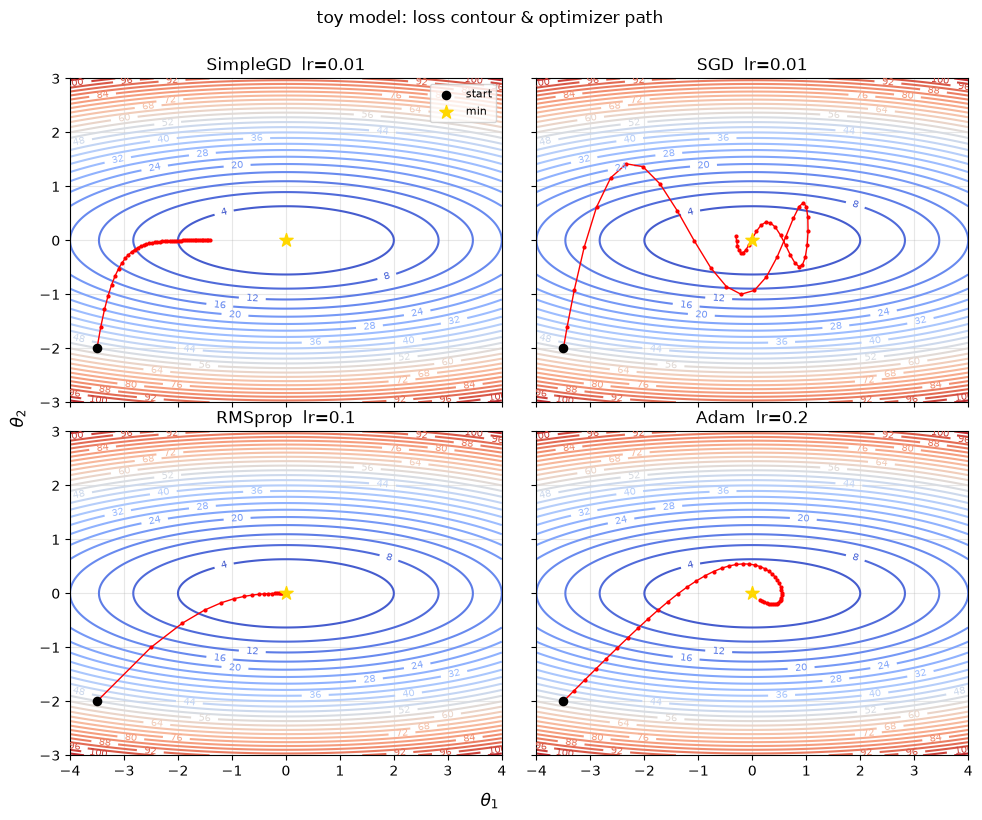

In [6]:
configs = [
    ("SimpleGD", 0.01),
    ("SGD", 0.01),
    ("RMSprop", 0.1),
    ("Adam", 0.2),
]

contours = plot_contours_subplots(configs, optimizers=OPTIMIZERS, steps=45)

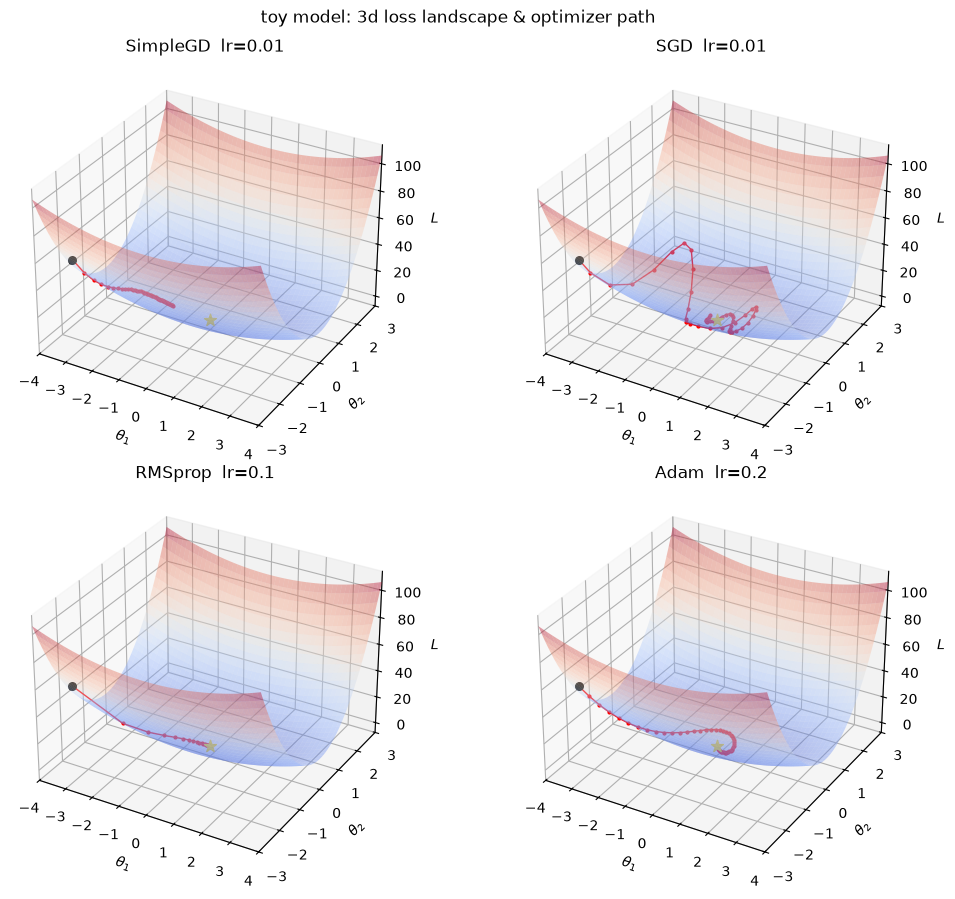

In [7]:
surface_3d = plot_surfaces_subplots(configs, optimizers=OPTIMIZERS, steps=45)

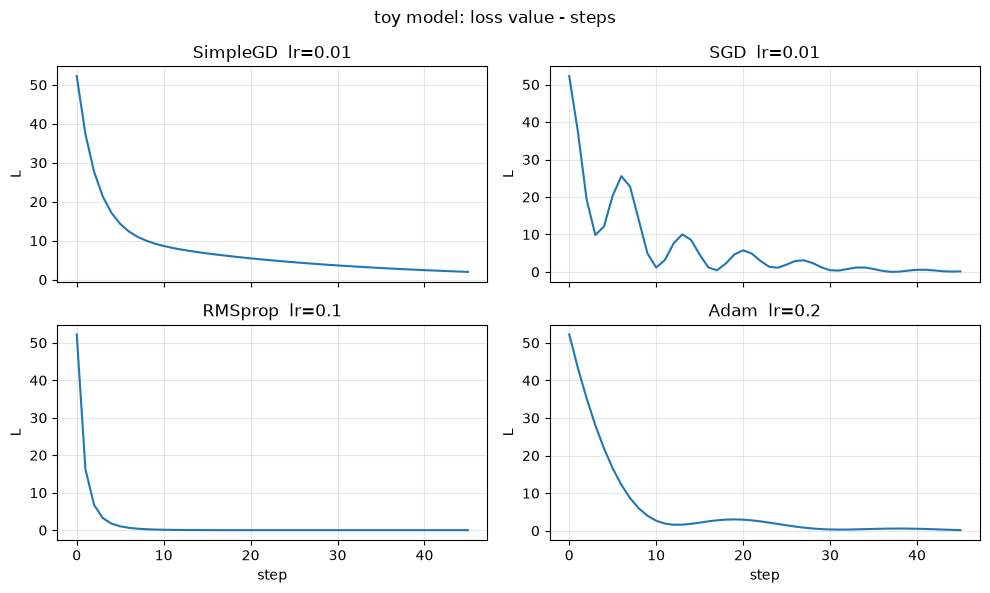

In [8]:
loss_steps = plot_loss_curves_subplots(configs, optimizers=OPTIMIZERS, steps=45)

#### 3.2) What's Special?

> $\eta$ stands for learning rate, $\mu$ stands for momentum.

On $L=\theta_1^2+10\theta_2^2$,

1. **Simple GD** works fine in this case, but it tends to take a more hesitant or zigzag path toward the origin for more cases, especially when we choose a higher learning rate. 
2. **Momentum** curves the trajectory and moves faster along the flat direction. But it's still gradient descent, zigzagging isn't completely fixed.
3. **RMSProp and Adam** adapt the step
along each axis, so they usually approach the minimum with less drama
once $\eta$ is in a reasonable range. 

But the ranking of paths still depends on the learning rate: (the visualization demonstrates well 🤔)

> **A “better” optimizer with a bad $\eta$ can look worse than simple GD with a good $\eta$.**

**Trade-offs**

| Optimizer | Strengths | Weaknesses |
|-----------|-----------|------------|
| SimpleGD | Simple; easy to interpret | Slow in narrow valleys; one global $\eta$ |
| SGD + Momentum | Accelerates along steady directions | Can overshoot; $\eta$ and $\mu$ both matter |
| RMSProp | Per-coordinate adaptive steps | Still needs a sensible $\eta$ |
| Adam | Strong default; fast early progress | Not always the best final generalization in vision; $\eta$ still matters |

The toy problem is noise-free and only two-dimensional. CIFAR-10 training
adds mini-batch noise and many more parameters, so in the next subsection, 
we're checking these behavior on a real CIFAR-10 model.


#### 3.3) Hello, My Model!

In [9]:
torch.manual_seed(0)
make_model = lambda: build_mlp(n_layers=0, n_hidd=256, use_batchnorm=False)

specs = [
    ("SimpleGD", lambda p: SimpleGD(p, lr=1e-2)),
    ("Momentum", lambda p: SGD(p, lr=1e-2, momentum=0.9)),
    ("RMSprop", lambda p: RMSprop(p, lr=1e-3)),
    ("Adam", lambda p: Adam(p, lr=3e-4)),
]

runs = {}
for name, opt_fn in specs:
    torch.manual_seed(0)
    model = make_model()
    runs[name] = {
        "model": model,
        "opt": opt_fn(model.parameters()),
        "history": [],
    }

loss_fn = CrossEntropyLoss()
loader = DataLoaderLite(X_train, y_train, batch_size=128, shuffle=True)

for epoch in range(5):
    for xb, yb in loader:
        for run in runs.values():
            run["history"].append(
                train_step(run["model"], loss_fn, run["opt"], xb, yb)
            )
    msg = ", ".join(
        f"{name}={run['history'][-1]:.4f}" for name, run in runs.items()
    )
    print(f"epoch {epoch + 1}: {msg}")

print("---summary---")
for name, run in runs.items():
    train_acc = accuracy(run["model"], X_train, y_train)
    test_acc = accuracy(run["model"], X_test, y_test)
    print(f"{name: <8} train {train_acc:.4f} test {test_acc:.4f}")

epoch 1: SimpleGD=1.8160, Momentum=1.4435, RMSprop=1.5402, Adam=1.4943
epoch 2: SimpleGD=1.6655, Momentum=1.4326, RMSprop=1.7042, Adam=1.4857
epoch 3: SimpleGD=1.6337, Momentum=1.4721, RMSprop=1.4584, Adam=1.4387
epoch 4: SimpleGD=1.4696, Momentum=1.3434, RMSprop=1.3590, Adam=1.2351
epoch 5: SimpleGD=1.5343, Momentum=1.3508, RMSprop=1.4916, Adam=1.2821
---summary---
SimpleGD train 0.4861 test 0.4733
Momentum train 0.5800 test 0.4875
RMSprop  train 0.5778 test 0.4958
Adam     train 0.5958 test 0.5187


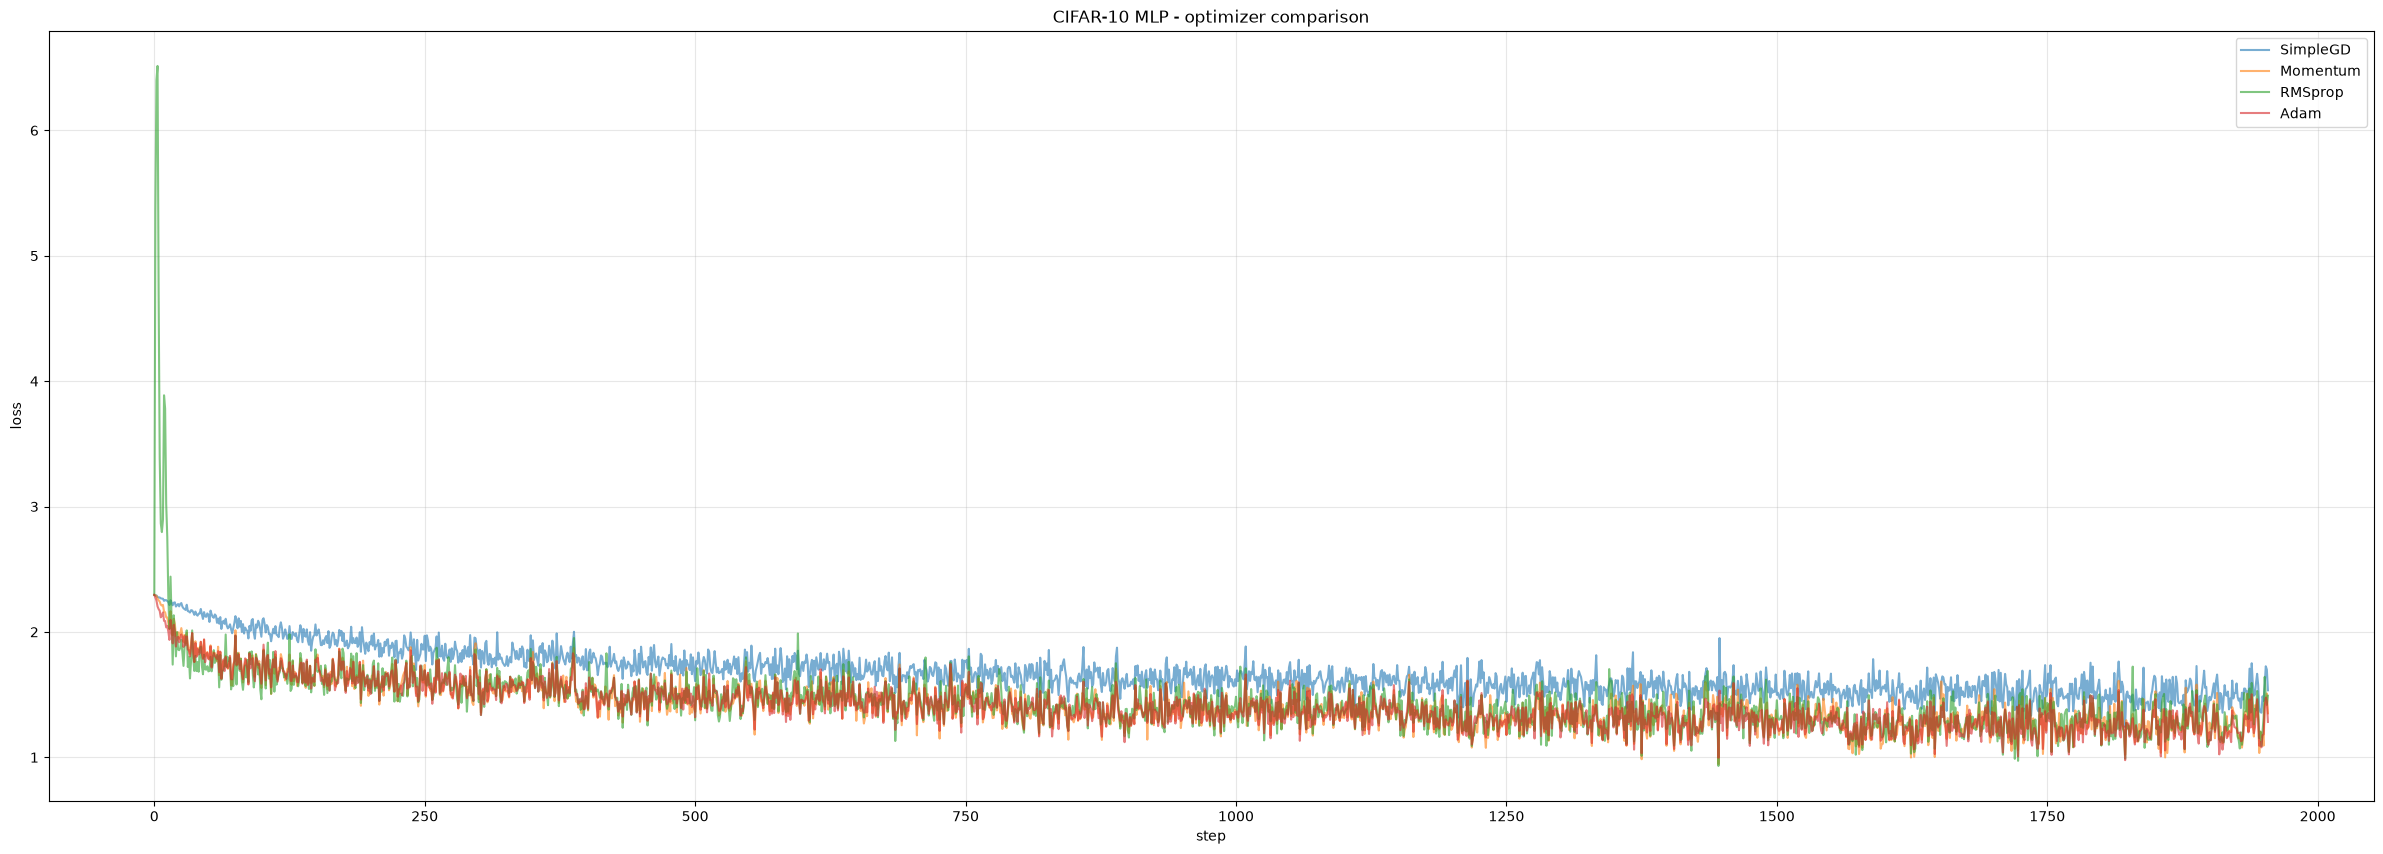

In [10]:
plt.figure(figsize=(30, 10))
for name, run in runs.items():
    plt.plot(run["history"], label=name, alpha=0.6)
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("CIFAR-10 MLP - optimizer comparison")
plt.grid(alpha=0.3)
plt.show()

### 4) Initializations

The optimizer comparison assumes a usable forward scale. Section 4 looks at initialization: without proper weight scaling, pre-activations can collapse or explode, and then optimizer curves become hard to interpret.

Okay, so far our first model works well, but something really detail hides in the net silently. you can find it out from the visualization below.

#### 4.1) Pre-activations & Visualizations

ReLU is our non-linearity; its gradient is simple:

$$\mathrm{ReLU}(x)=\begin{cases}x & x>0 \\ 0 & x\leqslant 0\end{cases},
\quad
\frac{\partial\mathrm{ReLU}}{\partial x}=\begin{cases}1 & x>0 \\ 0 & x\leqslant 0\end{cases}$$

> NOTE: $z$ is pre-activation, the output of Linearity, before ReLU.

In short, 

1. **The distribution shrinks**, after layers, $z$ piles up near zero.
2. **The input of deeper layers are weak**, deeper layers only see a very weak $h$, so unless weights are huge (usually unstable), the signal stays weak.
3. **Neurons learn slowly**, the weight gradients scale with activations, neurons learn slower with small gradients.

And here's why:

Without a proper weight scaling, the standard deviation of pre-activations often shrinks layer by layer in a deeper net, so $z$ piles up near zero.

In the forward pass, small pre-activations become small activations $h=\mathrm{ReLU}(z)$, so deeper layers receive a very weak signal and contribute little effective computation.

In the backward pass, ReLU’s local slope is only $0$ or $1$, but weight gradients still scale with the forward activations $h$ (`dW = h.T @ dz`). When $h$ is tiny, parameter updates become tiny as well; units with $z\leqslant 0$ also get zero ReLU gradient. Stacking many such layers makes learning very slow.

For saturating non-linearities such as $\tanh$, a *different* failure mode is also important: if pre-activations become *too large*, $\tanh'(z)\to 0$ and gradients vanish in the saturated regime. Collapse toward zero and explosion into saturation are both symptoms of bad scale, not the same mechanism. To know more about visualizing initializations and language model, this is [my blog post](https://telingc.github.io/2026/08/19/noob-neural-nets/).

too small gain (collapse)                | L1 mean=-0.0003 std=1.9585e-01
too small gain (collapse)                | L2 mean=-0.0008 std=2.6979e-02
too small gain (collapse)                | L3 mean=-0.0001 std=3.5351e-03
gain=1, no ReLU √2 (mild drift)          | L1 mean=-0.0142 std=9.8863e-01
gain=1, no ReLU √2 (mild drift)          | L2 mean=-0.0214 std=6.8700e-01
gain=1, no ReLU √2 (mild drift)          | L3 mean=+0.0296 std=4.8427e-01
too large gain (explosion)               | L1 mean=-0.0008 std=2.1002e+00
too large gain (explosion)               | L2 mean=-0.0053 std=2.2762e+00
too large gain (explosion)               | L3 mean=-0.0061 std=2.3235e+00
Kaiming gain=√2 (stable)                 | L1 mean=-0.0171 std=1.3398e+00
Kaiming gain=√2 (stable)                 | L2 mean=-0.0379 std=1.3372e+00
Kaiming gain=√2 (stable)                 | L3 mean=+0.0356 std=1.2916e+00


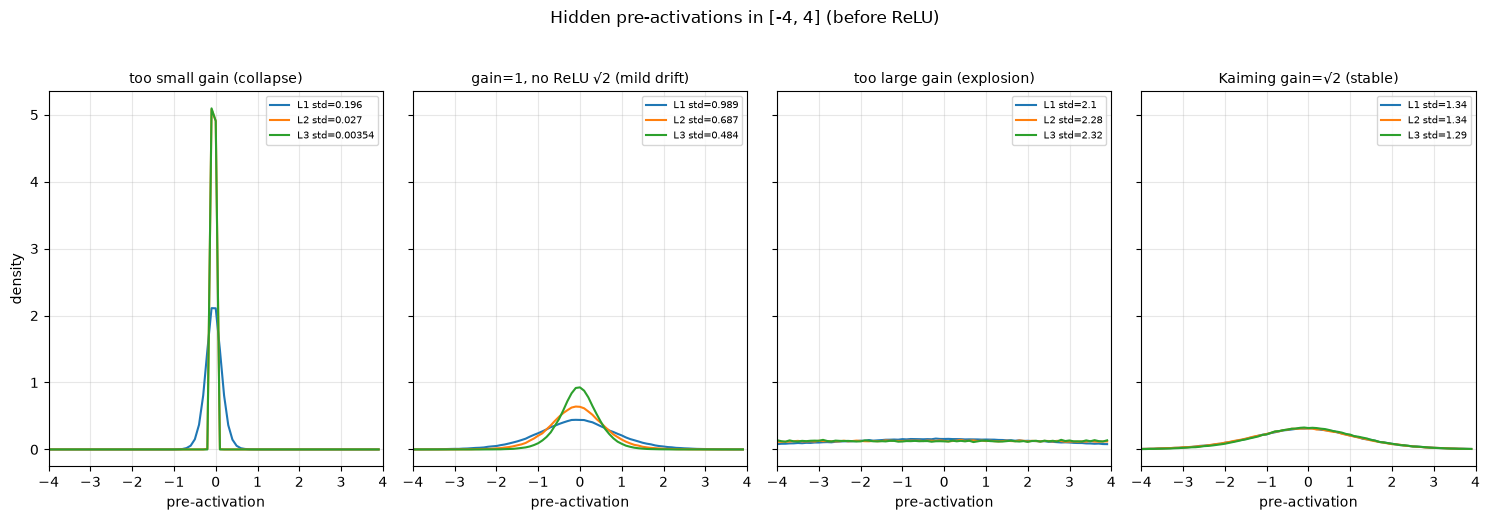

In [11]:
def make_preact_model(fan_in, n_hidd, n_hidden_layers, fan_out):
    layers = [Linear(fan_in, n_hidd), ReLU()]
    for _ in range(n_hidden_layers - 1):
        layers += [Linear(n_hidd, n_hidd), ReLU()]
    layers += [Linear(n_hidd, fan_out)]
    return Sequential(layers)


fig = plot_preact_four_gains(
    X_train[:1024],
    make_model=make_preact_model,
    n_hidden_layers=3,
    xlim=(-4, 4),
    figsize=(15, 5),
)
plt.show()

#### 4.2) Initializations
The problem revealed from the graph above is about **how to keep standard deviation stable?**.

We can scale weights by a factor that depends on fan-in and a gain for the non-linearity (e.g. $\sqrt{2}$ for ReLU).

- **It shrinks**, if the factor is too small.
- **It expands**, if the factor is too large.

Kaiming He's team figured out a way to deal with the problem, that was called [*Kaiming Init*](https://arxiv.org/abs/1502.01852) or *He init*.

Now I'm skipping the mathematics and write the result of the Kaiming Init paper:

**Kaiming / He (normal):**

$$
W \sim \mathcal{N}(0,\ \sigma^2),
\quad
\sigma = \frac{\mathrm{gain}}{\sqrt{\mathrm{fan}}}
$$

| Nonlinearity | Gain |
|--------------|------|
| linear / identity | $1$ |
| sigmoid | $1$ |
| tanh | $\frac{5}{3}$ |
| ReLU | $\sqrt{2}$ |
| Leaky ReLU (negative slope $a$) | $\sqrt{2/(1+a^2)}$ |
| SELU | $\frac{3}{4}$ |

For ReLU with $\mathrm{fan}=\mathrm{fan_in}$ and $\mathrm{gain}=\sqrt{2}$:

$$
\sigma = \sqrt{\frac{2}{\mathrm{fan\_in}}}
$$

In [12]:
def kaiming_uniform_(w, nonlinearity="relu"):
    fan_in = w.shape[0]
    gain = math.sqrt(2.0) if nonlinearity == "relu" else 1.0
    bound = math.sqrt(3.0) * gain / math.sqrt(fan_in)
    return w.uniform_(-bound, bound)

#### 4.3) Gaussian & Xavier

Before Kaiming, Fixed Gaussian scale or **Xavier Init**
initialization (especially with $\tanh$) are common choices.

1. **Gaussian**  

$$
W \sim \mathcal{N}(0,\ \sigma^2)
$$

**It's just fix the distribution. It works, but less flexible.**

with a hand-chosen $\sigma$ (e.g. $0.01$). It doesn't depend on
$\mathrm{fan_in}$ / $\mathrm{fan_out}$, so depth or width changes can
make the scale too small or too large.

2. **Xavier**

Keep variance stable for symmetric activations.

$$
W \sim \mathcal{N}\!\left(0,\ \frac{2}{n_{\mathrm{in}}+n_{\mathrm{out}}}\right)
\quad\text{or}\quad
W \sim U\!\left(-\sqrt{\frac{6}{n_{\mathrm{in}}+n_{\mathrm{out}}}},\
\sqrt{\frac{6}{n_{\mathrm{in}}+n_{\mathrm{out}}}}\right)
$$

Xavier is a strong default for $\tanh$-like units. For ReLU, Kaiming
(with $\mathrm{gain}=\sqrt{2}$) is usually more appropriate.

In [13]:
def gaussian_(w, std=0.01):
    return w.normal_(0.0, std)


def xavier_uniform_(w, gain=1.0):
    fan_in, fan_out = w.shape
    bound = gain * math.sqrt(6.0 / (fan_in + fan_out))
    return w.uniform_(-bound, bound)

#### 4.4) Putting It Together

With pre-activation scales under control, training becomes a fairer test of
optimizers and learning-rate choices: the network is less likely to fail
only because the signal vanished or exploded at initialization.

In [14]:
model = build_mlp(
    n_layers=1,
    n_hidd=256,
    use_batchnorm=False,
    last_scale=1.0,
)


def init_model(model, method="kaiming"):
    for layer in model.layers:
        if not isinstance(layer, Linear):
            continue
        if method == "kaiming":
            kaiming_uniform_(layer.weight, nonlinearity="relu")
        elif method == "xavier":
            xavier_uniform_(layer.weight)
        elif method == "gaussian":
            gaussian_(layer.weight, std=0.01)
        else:
            raise ValueError(method)
        if layer.bias is not None:
            layer.bias.zero_()


init_model(model, method="kaiming")
scale_last_layer(model, 0.1)

In [15]:
loss_fn = CrossEntropyLoss()
opt = Adam(model.parameters(), lr=3e-4)
loader = DataLoaderLite(X_train, y_train, batch_size=128, shuffle=True)

loss_history = []
for epoch in range(5):
    for xb, yb in loader:
        loss = train_step(model, loss_fn, opt, xb, yb)
        loss_history.append(loss)
    print(f"epoch {epoch + 1}, last loss {loss:.4f}")

train_acc = accuracy(model, X_train, y_train)
test_acc = accuracy(model, X_test, y_test)
print("train acc", train_acc)
print("test  acc", test_acc)

epoch 1, last loss 1.3385
epoch 2, last loss 1.4784
epoch 3, last loss 1.3524
epoch 4, last loss 1.1349
epoch 5, last loss 1.1832
train acc 0.63192
test  acc 0.5379


### 5) Normalizations

![pencil](images/BalancingPencilChallenge.png "Figure 3: Balancing a pencil.")

So far, training a neural net can be tricky and parameters seems fragile. Tuning and understanding is much like balancing a pencil, a pure torture. 😫

And now we're introducing normalizations, a way to make the net less sensitive.

#### 5.1) BatchNorm

Precisely tuned, fragile initializations matter less today thanks to some modern innovations — one of which is batch normalization. So if you want a standard Gaussian for initialization, why not just *make* it Gaussian?

Statistically, scaling up by a factor of $n$ enlarges the standard deviation by $n$. 

So,

- if you need to center the distribution at zero, just subtract the mean of the pre-activations; 
- if you want unit variance, just divide by the standard deviation. 

And most importantly, all of this is built into the neural net — meaning we can ensure a roughly standard-normal pre-activation every iteration, firing the non-linearity at full capacity, and even giving the net extra parameter knobs to tune for a better fit.

Let's take a close look at these formulas, because they're simple and useful. For multi-layer nets it makes training more forgiving.

1. $\text{the mean of the pre-activations}$

$$\frac{1}{m}\sum_{i=1}^{m}x_i = \mu_{\mathcal{B}}$$

2. $\text{the variance of the pre-activations}$

$$\frac{1}{m-1}\sum_{i=1}^{m}(x_i-\mu_{\mathcal{B}})^2 = \sigma_{\mathcal{B}}^2$$

3. $\text{normalization}$

$$\frac{x_i-\mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2+\epsilon}} = \hat{x_i}$$

4. $\text{scale and shift}$

$$\gamma\hat{x_i}+\beta = y_i \equiv \mathrm{BN}_{\gamma,\beta}(x_i)$$

For more details, here's [Andrej Karpathy](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ).

In [16]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.gamma.grad = None
        self.beta.grad = None
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            mean = x.mean(0)
            var = x.var(0, unbiased=False)
            with torch.no_grad():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * mean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * var
        else:
            mean = self.running_mean
            var = self.running_var

        xhat = (x - mean) / torch.sqrt(var + self.eps)
        self.out = self.gamma * xhat + self.beta
        self._cache = (x, xhat, mean, var)
        return self.out

    def backward(self, dout):
        x, xhat, mean, var = self._cache
        dgamma = (dout * xhat).sum(0)
        dbeta = dout.sum(0)
        self.gamma.grad = dgamma if self.gamma.grad is None else self.gamma.grad + dgamma
        self.beta.grad = dbeta if self.beta.grad is None else self.beta.grad + dbeta

        dxhat = dout * self.gamma
        inv_std = 1.0 / torch.sqrt(var + self.eps)
        n = x.shape[0]
        dx = (1.0 / n) * inv_std * (
            n * dxhat - dxhat.sum(0) - xhat * (dxhat * xhat).sum(0)
        )
        return dx

    def parameters(self):
        return [self.gamma, self.beta]

#### 5.2) LayerNorm

> NOTE: This part will be covered later.

In [17]:
class LayerNorm:
    def __init__(self, dim, eps=1e-5):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.gamma.grad = None
        self.beta.grad = None

    def __call__(self, x):
        mean = x.mean(-1, keepdim=True)
        var = x.var(-1, keepdim=True, unbiased=False)
        xhat = (x - mean) / torch.sqrt(var + self.eps)
        self.out = self.gamma * xhat + self.beta
        self._cache = (x, xhat, mean, var)
        return self.out

    def backward(self, dout):
        x, xhat, mean, var = self._cache
        dgamma = (dout * xhat).sum(0)
        dbeta = dout.sum(0)
        self.gamma.grad = dgamma if self.gamma.grad is None else self.gamma.grad + dgamma
        self.beta.grad = dbeta if self.beta.grad is None else self.beta.grad + dbeta

        dxhat = dout * self.gamma
        inv_std = 1.0 / torch.sqrt(var + self.eps)
        dx = inv_std * (
            dxhat
            - dxhat.mean(-1, keepdim=True)
            - xhat * (dxhat * xhat).mean(-1, keepdim=True)
        )
        return dx

    def parameters(self):
        return [self.gamma, self.beta]

### 6) Hyperparameters

Hyperparameters, you can imagine them a bunch of knobs you can play with.

And these two params are unchangable.
- **FAN_IN**: The input is a $32\text{px}\times32\text{px}$ picture with $3$ channels: RGB, so `FAN_IN` can and only be $32\times32\times3=3072$.
- **FAN_OUT**: We're classifing pictures into 10 classes, so the `FAN_OUT` can and only be $10$.

Here's what we can use to optimize the net:

1. `learning_rate`, learning rate.

2. `n_epoch`, how many times (steps / epoches) the net will be trained.

3. `n_layers`, the depth of the net.

4. `n_hidd`, the dimension of the hidden layer.

5. `batch_size`, the size of mini-batches.

#### 6.1) Some Experiments on Hyperparameters

So the idea is simple, keep other parameters fixed and tune one parameter per experiment.
From the table drawn below, increasing the scale of the hidden layer is a promising choice.

We achieved $\approx54\text{ percent}$ accuracy on the validation set, and the loss value came to $\approx 1$. But note that the accuracy gap between val and train is the highest among the experiments, our model may be over-fitting the dataset.

---layers---
[1/5] n_layers=0 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.4984  train 0.5892  loss 1.2751  (4.0s)
[2/5] n_layers=1 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.5232  train 0.6338  loss 1.1638  (5.0s)
[3/5] n_layers=2 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.5170  train 0.6494  loss 1.1364  (6.9s)
[4/5] n_layers=4 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.5148  train 0.6627  loss 1.1302  (9.6s)
[5/5] n_layers=8 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.4992  train 0.6440  loss 1.2100  (15.4s)
---hidd---
[1/4] n_layers=2 n_hidd=16 batch_size=128 lr=0.0003
    -> val 0.4114  train 0.4344  loss 1.6178  (2.3s)
[2/4] n_layers=2 n_hidd=64 batch_size=128 lr=0.0003
    -> val 0.4820  train 0.5545  loss 1.3471  (3.5s)
[3/4] n_layers=2 n_hidd=256 batch_size=128 lr=0.0003
    -> val 0.5170  train 0.6494  loss 1.1364  (6.6s)
[4/4] n_layers=2 n_hidd=1024 batch_size=128 lr=0.0003
    -> val 0.5360  train 0.7171  loss 1.0011  (27.0s)
---batch---
[1/5] n_l

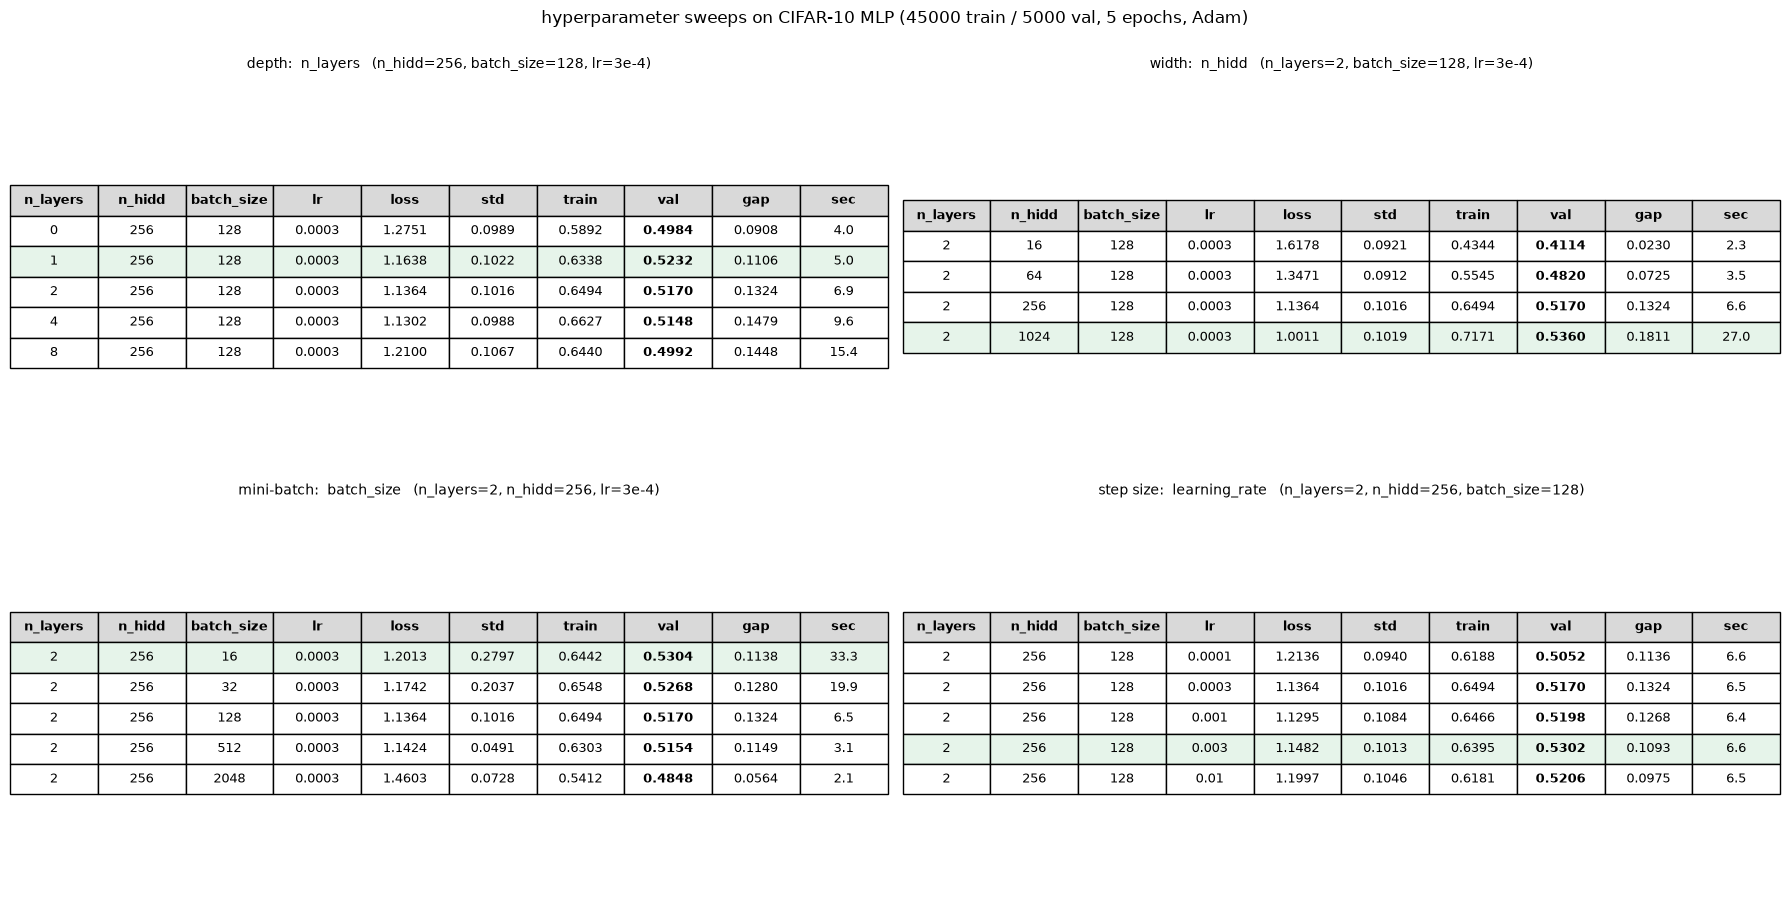

In [18]:
FAN_IN, FAN_OUT = 3072, 10
N_TRAIN, N_VAL = 45000, 5000
N_EPOCH = 5

JOBS = {
    "layers": [(d, 256, 128, 3e-4) for d in (0, 1, 2, 4, 8)],
    "hidd": [(2, h, 128, 3e-4) for h in (16, 64, 256, 1024)],
    "batch": [(2, 256, b, 3e-4) for b in (16, 32, 128, 512, 2048)],
    "lr": [(2, 256, 128, lr) for lr in (1e-4, 3e-4, 1e-3, 3e-3, 1e-2)],
}

LABELS = {
    "layers": "depth:  n_layers   (n_hidd=256, batch_size=128, lr=3e-4)",
    "hidd": "width:  n_hidd   (n_layers=2, batch_size=128, lr=3e-4)",
    "batch": "mini-batch:  batch_size   (n_layers=2, n_hidd=256, lr=3e-4)",
    "lr": "step size:  learning_rate   (n_layers=2, n_hidd=256, batch_size=128)",
}

Xtr, ytr, Xva, yva = make_train_val_split(
    X_train,
    y_train,
    n_train=N_TRAIN,
    n_val=N_VAL,
    seed=0,
)


def run_config(n_layers, n_hidd, batch_size, lr, n_epoch, verbose=False):
    torch.manual_seed(0)
    model = build_mlp(n_layers, n_hidd, use_batchnorm=True)
    loss_fn = CrossEntropyLoss()
    opt = Adam(model.parameters(), lr=lr)
    loader = DataLoaderLite(Xtr, ytr, batch_size=batch_size, shuffle=True)

    history = []
    t0 = time.time()
    for epoch in range(n_epoch):
        for xb, yb in loader:
            history.append(train_step(model, loss_fn, opt, xb, yb))
        if verbose:
            print(
                f"    epoch {epoch + 1}/{n_epoch}  "
                f"loss {np.mean(history[-50:]):.4f}"
            )

    return {
        "n_layers": n_layers,
        "n_hidd": n_hidd,
        "batch_size": batch_size,
        "lr": lr,
        "n_epoch": n_epoch,
        "loss_first": history[0],
        "loss_last50": float(np.mean(history[-50:])),
        "loss_std50": float(np.std(history[-50:])),
        "train_acc": accuracy(model, Xtr, ytr),
        "val_acc": accuracy(model, Xva, yva),
        "seconds": time.time() - t0,
        "history": history,
    }


def sweep(jobs, n_epoch=N_EPOCH, verbose=False):
    results = []
    for i, (n_layers, n_hidd, batch_size, lr) in enumerate(jobs, 1):
        print(
            f"[{i}/{len(jobs)}] n_layers={n_layers} n_hidd={n_hidd} "
            f"batch_size={batch_size} lr={lr}",
            flush=True,
        )
        result = run_config(n_layers, n_hidd, batch_size, lr, n_epoch, verbose=verbose)
        print(
            f"    -> val {result['val_acc']:.4f}  "
            f"train {result['train_acc']:.4f}  "
            f"loss {result['loss_last50']:.4f}  "
            f"({result['seconds']:.1f}s)"
        )
        results.append(result)
    return results


results_all = {}
for name, jobs in JOBS.items():
    print(f"---{name}---")
    results_all[name] = sweep(jobs, n_epoch=N_EPOCH, verbose=False)

ncols = 2
nrows = -(-len(JOBS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, JOBS):
    plot_table(results_all[name], ax, LABELS[name])
for ax in axes[len(JOBS):]:
    ax.axis("off")
fig.suptitle(
    f"hyperparameter sweeps on CIFAR-10 MLP "
    f"({N_TRAIN} train / {N_VAL} val, {N_EPOCH} epochs, Adam)",
    y=1.0,
)
fig.tight_layout()
plt.show()

#### 6.2) Visualizations

So far we've done quite a lot visualizations, it's a good choice to draw a graph and visualise it. Let's take initializations for example, improper initializations are dragging the overall performance silently, it's quite tricky to debug. But visualizing the pre-activations of each layer gives an intuitive understanding.

But experimenting with different hyperparameters is the best way still. We can summarize some empirical conclusions next section.

#### 6.3) Some Empirical Methods

Before changing anything, here are two signals:

- **loss curve** → is optimization working?
- **train / val gap** → is capacity fitting or overfitting?

**Turn one knob at a time**. Fix the curve first (`learning_rate`, `batch_size`), then capacity (`n_hidd`, `n_layers`), then train longer (`n_epoch`).

1. **learning_rate**

If the loss falls very slowly (almost a straight line), try a larger lr.
If the loss is violent, jumps up, or becomes `nan`, use a smaller lr.
A shaky curve is not only about lr: small `batch_size` also adds noise, so check both.
With Adam, a wide lr range can look similar on accuracy; still watch the loss — too large an lr often makes the final loss rise again.

2. **n_epoch**

Train while validation accuracy improves. If train accuracy keeps rising but val flattens or drops, you are starting to overfit — stop, regularize, or get more data; more epochs alone will usually widen the gap.
Use a real validation split for this decision; do not tune on the test set.

3. **n_layers**

Depth adds capacity, but it saturates fast on this MLP.
If both train and val are low and close (underfit), add a block.
If val stops improving while train still climbs, extra depth mostly memorizes and costs more time.
A deeper net that “does not learn” is often a scale / init issue (Section 4), not “not enough layers.”

4. **n_hidd**

Usually the first capacity knob when the model underfits: wider hidden layers tend to raise both train and val accuracy.
When $\text{train}\geqslant\text{val}$, width is no longer the bottleneck — use regularization or more data, and prefer the **smallest** width where val saturates.

5. **batch_size**

**Small** batches → noisier loss, more updates per epoch, noise acts a bit like regularization.
**Large** batches → smoother loss, fewer updates per epoch; with fixed `n_epoch` the loss may fall slower unless lr is increased. Tune `batch_size` and `learning_rate` together.

### 7) Training

Now we can test and train a model.

In [19]:
torch.manual_seed(0)

n_layers = 1
n_epoch = 5
n_hidd = 1024
batch_size = 16
learning_rate = 3e-3

model = build_mlp(
    n_layers=n_layers,
    n_hidd=n_hidd,
    use_batchnorm=True,
)

In [20]:
loss_fn = CrossEntropyLoss()
opt = Adam(model.parameters(), lr=learning_rate)
loader = DataLoaderLite(
    X_train,
    y_train,
    batch_size=batch_size,
    shuffle=True,
)

loss_history = []
for epoch in range(n_epoch):
    for xb, yb in loader:
        loss = train_step(model, loss_fn, opt, xb, yb)
        loss_history.append(loss)
    print(f"epoch {epoch + 1}, last loss {loss:.4f}")

epoch 1, last loss 1.7340
epoch 2, last loss 1.2211
epoch 3, last loss 1.2460
epoch 4, last loss 1.6345
epoch 5, last loss 1.0630


In [21]:
train_acc = accuracy(model, X_train, y_train)
test_acc = accuracy(model, X_test, y_test)
print("train acc", train_acc)
print("test  acc", test_acc)
print("gap      ", abs(train_acc - test_acc))

train acc 0.6466
test  acc 0.5397
gap       0.1069


### 8) Next Steps

Now you might wonder: **why this notebook is far more complex than the numpy version?**

In this version, our implementations are corresponding with the PyTorch API using. And we're using GPU for computation which is much faster than NumPy.

For next steps, we'll implement CNN. By then we could find that the CNN has higher accuracy ($\approx 80\text{ percent}$) and higher confidence in general, and that means CNN is more likely to make wrong predictions confidently.

Now, if you ever feel curious about the fancy GIF picture in the 0) Intro, code here provides you a real time version, 2 neural nets (MLP and CNN, CNN will be implement in future versions) run directly in this notebook **in real time**.

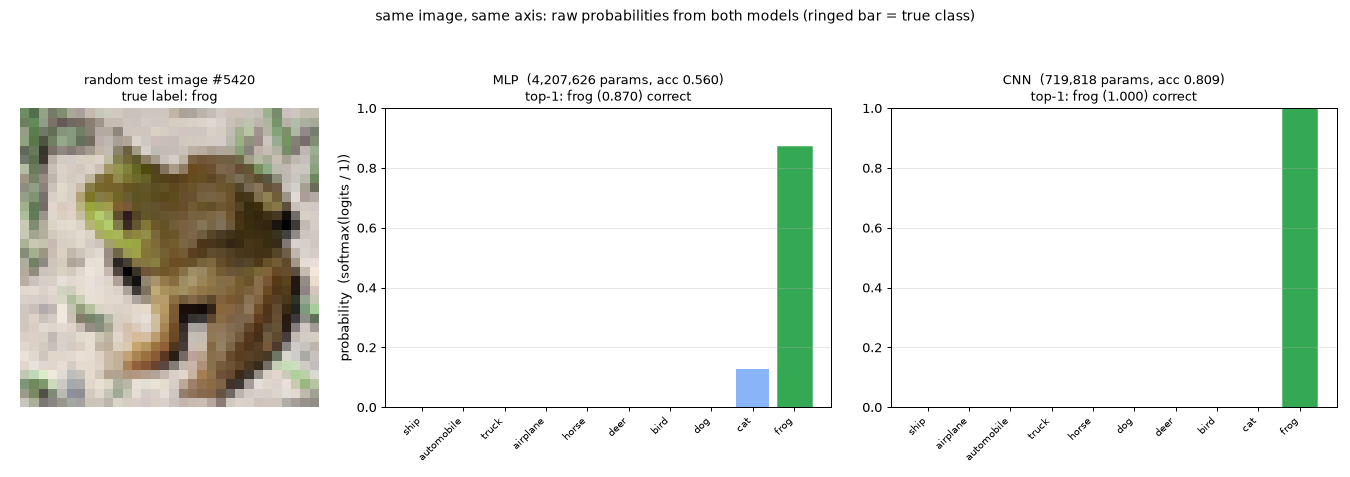

[1/50] image #4355  true=airplane   | MLP top1=bird       ok=False bars>0.01=4 | CNN top1=airplane   ok=True bars>0.01=2
[2/50] image #9418  true=ship       | MLP top1=automobile ok=False bars>0.01=1 | CNN top1=ship       ok=True bars>0.01=2
[3/50] image #9960  true=bird       | MLP top1=airplane   ok=False bars>0.01=1 | CNN top1=airplane   ok=False bars>0.01=1
[4/50] image #6006  true=airplane   | MLP top1=airplane   ok=True bars>0.01=7 | CNN top1=airplane   ok=True bars>0.01=1
[5/50] image #4620  true=horse      | MLP top1=cat        ok=False bars>0.01=2 | CNN top1=horse      ok=True bars>0.01=2
[6/50] image #5990  true=ship       | MLP top1=airplane   ok=False bars>0.01=4 | CNN top1=ship       ok=True bars>0.01=1
[7/50] image #3178  true=dog        | MLP top1=bird       ok=False bars>0.01=3 | CNN top1=horse      ok=False bars>0.01=2
[8/50] image #1452  true=frog       | MLP top1=cat        ok=False bars>0.01=2 | CNN top1=frog       ok=True bars>0.01=1
[9/50] image #6175  true=cat   

In [22]:
def make_mlp(hidden=1024, blocks=1, n_classes=10, in_features=3072):
    layers = [nn.Flatten(), nn.Linear(in_features, hidden), nn.ReLU(inplace=True)]
    for _ in range(blocks):
        layers += [
            nn.Linear(hidden, hidden, bias=False),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
        ]
    layers += [nn.Linear(hidden, n_classes)]
    return nn.Sequential(*layers)


def make_cnn(width=64, n_classes=10):
    def block(cin, cout):
        return [
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        ]

    return nn.Sequential(
        *block(3, width),
        *block(width, width),
        nn.MaxPool2d(2),
        *block(width, 2 * width),
        *block(2 * width, 2 * width),
        nn.MaxPool2d(2),
        *block(2 * width, 4 * width),
        nn.Flatten(),
        nn.Linear(4 * width * 8 * 8, n_classes),
    )


BUILDERS = {
    "mlp": lambda arch: make_mlp(hidden=arch["hidden"], blocks=arch["blocks"]),
    "cnn": lambda arch: make_cnn(width=arch["width"]),
}

ctx = load_comparison_context(BUILDERS)
log = run_live_demo(ctx, n_images = 50)
print("\n".join(log))

### 9) Conclusion

Hand-written training is slower to write than `loss.backward()`, but every
knob stays visible: the scale of pre-activations, the shape of the loss
curve, and the train/val gap.

#### 9.1) Practical Takeaways

**Dataset.** Normalize with the **training** set mean/std. Tune on a
**validation** split; touch the test set only for the final number.

**Optimizers.** Compare methods under the same step budget and plot loss
against step. Toy contour plots explain paths; CIFAR curves show noise.
A “better” optimizer with a bad learning rate can lose to GD with a good
one. Helpers: `plot_contours_subplots`, `plot_loss_curves_subplots`
(pass in your `optimizers` map).

**Initialization — check pre-activations.**
After you change depth, width, or init, run **one forward batch** and look
at the pre-activation scale **before** ReLU. Collapse or explosion shows up
before you waste a full training run. For ReLU, Kaiming uses

$$
\sigma = \frac{\mathrm{gain}}{\sqrt{\mathrm{fan}}},
\quad \mathrm{gain}=\sqrt{2}
$$

Shrinking the last layer (e.g. $\times 0.1$) keeps the initial loss near
$\log C$ (about $2.3$ for CIFAR-10).

**Normalization.** BatchNorm recenters and rescales each batch (with
learned $\gamma, \beta$), so deeper MLPs are less fragile than init-only
training.

**Hyperparameters.** Change one knob at a time. Suggested order:
learning rate and batch size (stabilize the curve) → width / depth
(capacity) → epochs. In our sweeps, width helped validation most;
extra depth saturated and widened the train/val gap. Summarize sweeps with
`plot_table`.

**Final run.** Report train accuracy, test accuracy, and the gap. A
large gap is about capacity, regularization, or data.

**MLP vs CNN (demo).** On the same image, compare full probability bars,
not only top-1. Higher accuracy often comes with a sharper softmax;
a wrong answer can still look very confident.

#### 9.2) In Short

Get the scale right, read the curve and the gap,
turn one hyperparameter at a time—then try a CNN without throwing away
these habits.

### 10) LLM Use & Statement

**Tools.** 
- **LLMs** Implementation and refactoring were mostly assisted by coding agents, mainly DeepSeek V4 Flash under the Codex harness to be specific. Grok was used for conceptual review (toy optimizers vs CIFAR runs, initialization wording, notebook structure) and for English drafts that I edited against the actual outputs.
- **Environment** Datasets and codes run locally on VSCode.

**My part.** 
- **Experiment choices**, the concrete designing of these experiments.
- **Figure design**, I edited most of the pictures (the cover for example), the pencil balancing picture is the only picture obtained from internet.
- **The overall architecture**, I split the notebook into chapters and sections to make it more readable.
- **Reports**
- **Text drafts and decisions**, Every text in the notebook was **polished** by LLMs, I wrote these drafts firstly.

**Non-LLM sources.**
- Andrej Karpathy, [Neural Networks: Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ)
- [CS231n](https://cs231n.stanford.edu/) (CIFAR-10 practice, initialization, training tips)
- Earlier notes: [Visualizing a simple neural network under the hood](https://telingc.github.io/2026/08/19/noob-neural-nets/)